In [1]:
pip install tensorflow_datasets

In [2]:
import tensorflow_datasets as tfds
import numpy as np
import tensorflow as tf

In [3]:
imdb, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.TD8537_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.TD8537_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.TD8537_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [4]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_e

In [5]:
imdb

{Split('train'): <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 Split('test'): <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 Split('unsupervised'): <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}

In [6]:
train_data, test_data = imdb['train'], imdb['test']

In [7]:
training_sentences = []
training_labels = []
testing_sentences = []
testing_labels = []

for s, l in train_data:
    training_sentences.append(str(s.numpy()))
    training_labels.append(l.numpy())

for s, l in test_data:
    testing_sentences.append(str(s.numpy()))
    testing_labels.append(l.numpy())

In [8]:
testing_sentences[0]

'b"There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smith, CLERKS; for Robert Rodriguez, EL MARIACHI. Add to that list Onur Tukel\'s absolutely amazing DING-A-LING-LESS. Flawless film-making, and as assured and as professional as any of the aforementioned movies. I haven\'t laughed this hard since I saw THE FULL MONTY. (And, even then, I don\'t think I laughed quite this hard... So to speak.) Tukel\'s talent is considerable: DING-A-LING-LESS is so chock full of double entendres that one would have to sit down with a copy of this script and do a line-by-line examination of it to fully appreciate the, uh, breadth and width of it. Every shot is beautifully composed (a clear sign of a sure-handed director), and the performances all around are solid (there\'s none of the over-the-top scenery chewing one might\'ve expected from a film like this). DING-A-LING-LESS is a film whose time has come."'

In [9]:
testing_labels[0]

np.int64(1)

In [10]:
len(training_sentences), len(testing_sentences)

(25000, 25000)

In [11]:
len(training_labels), len(testing_labels)

(25000, 25000)

In [12]:
training_labels = np.array(training_labels)
testing_labels  = np.array(testing_labels)

#### Preprocessing

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [14]:
help(Tokenizer)

Help on class Tokenizer in module keras.src.legacy.preprocessing.text:

class Tokenizer(builtins.object)
 |  Tokenizer(num_words=None, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True, split=' ', char_level=False, oov_token=None, analyzer=None, **kwargs)
 |
 |  DEPRECATED.
 |
 |  Methods defined here:
 |
 |  __init__(self, num_words=None, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True, split=' ', char_level=False, oov_token=None, analyzer=None, **kwargs)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  fit_on_sequences(self, sequences)
 |
 |  fit_on_texts(self, texts)
 |
 |  get_config(self)
 |
 |  sequences_to_matrix(self, sequences, mode='binary')
 |
 |  sequences_to_texts(self, sequences)
 |
 |  sequences_to_texts_generator(self, sequences)
 |
 |  texts_to_matrix(self, texts, mode='binary')
 |
 |  texts_to_sequences(self, texts)
 |
 |  texts_to_sequences_generator(self, texts)
 |
 |  to_json(self, **kwargs)
 |
 |  ------------------

In [15]:
tokenizer = Tokenizer(num_words=10000)

In [16]:
type(training_sentences[0])

str

In [17]:
tokenizer.fit_on_texts(training_sentences)

In [18]:
word_index = tokenizer.word_index

In [19]:
sequences = tokenizer.texts_to_sequences(training_sentences)
padded = pad_sequences(sequences, maxlen=500,
                       truncating='post', padding='post')
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=500,
                       truncating='post', padding='post')

In [20]:
padded.shape

(25000, 500)

In [21]:
padded[0]

array([  58,   11,   13,   34,  438,  399,   17,  173,   28,    8,   32,
       1377, 3400,   41,  495,  196,   24,   87,  155,   18,   11,  210,
        339,   28,   69,  247,  212,    8,  485,   61,   69,   87,  115,
         98,   23, 5739,   11, 3316,  656,  776,   11,   17,    6,   34,
        405, 8227,  177, 2476,  425,    1,   91, 1252,  139,   71,  148,
         54,    1, 7524,   71,  228,   69, 2961,   15, 2879, 1505, 4997,
          2,   39, 3946,  118, 1607,   16, 3400,   13,  162,   18,    3,
       1252,  926, 7985,    8,    3,   17,   12,   13, 4199,    4,  101,
        147, 1236,   10,  239,  691,   12,   43,   24,  100,   38,   11,
       7231,   38, 1377,   51,  408,   10,   98, 1213,  873,  144,    9,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

#### Build the model

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Embedding, SimpleRNN, Bidirectional, LSTM, GRU

##### Simple RNN

In [23]:
model_rnn = Sequential([
    Embedding(10000, 50, input_length=500),
    SimpleRNN(32),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
model_rnn.compile(loss='binary_crossentropy', optimizer='adam',
                 metrics=['accuracy'])

In [25]:
training_labels

array([0, 0, 0, ..., 0, 0, 1])

In [26]:
history = model_rnn.fit(padded, training_labels, epochs=10,
                       validation_data=(testing_padded, testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.5012 - loss: 0.6937 - val_accuracy: 0.5039 - val_loss: 0.6935
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.5032 - loss: 0.6938 - val_accuracy: 0.5034 - val_loss: 0.6985
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5085 - loss: 0.6930 - val_accuracy: 0.5066 - val_loss: 0.6942
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5085 - loss: 0.6929 - val_accuracy: 0.4995 - val_loss: 0.6938
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5096 - loss: 0.6919 - val_accuracy: 0.5040 - val_loss: 0.6934
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5200 - loss: 0.6886 - val_accuracy: 0.5040 - val_loss: 0.6940
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5244 - loss: 0.6834 - val_accuracy: 0.5037 - val_loss: 0.6977
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5190 - loss: 0.6757 - 

In [27]:
import matplotlib.pyplot as plt

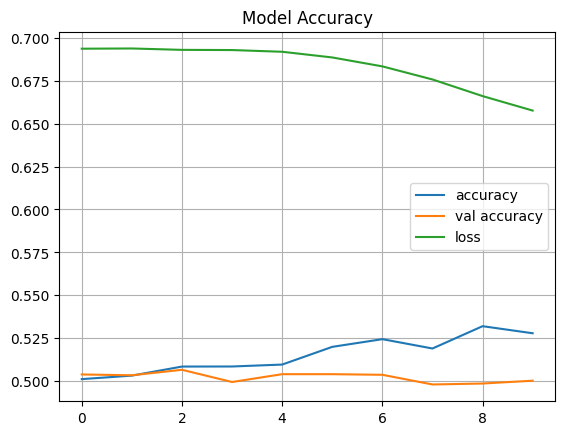

In [28]:
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val accuracy')
plt.plot(history.history['loss'], label = 'loss')
plt.title('Model Accuracy')
plt.grid()
plt.legend()

*LSTM Model*

In [29]:
model_lstm = Sequential([
    Embedding(10000, 50, input_length=500),
    LSTM(32),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [30]:
model_lstm.compile(loss='binary_crossentropy', optimizer='adam',
                 metrics=['accuracy'])

In [31]:
history_lstm = model_lstm.fit(padded, training_labels, epochs=10,
                       validation_data=(testing_padded, testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.5083 - loss: 0.6929 - val_accuracy: 0.5081 - val_loss: 0.6921
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5202 - loss: 0.6819 - val_accuracy: 0.5076 - val_loss: 0.6953
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5358 - loss: 0.6553 - val_accuracy: 0.5077 - val_loss: 0.7148
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5372 - loss: 0.6438 - val_accuracy: 0.5106 - val_loss: 0.7445
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5420 - loss: 0.6412 - val_accuracy: 0.5066 - val_loss: 0.7582
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5397 - loss: 0.6400 - val_accuracy: 0.5118 - val_loss: 0.7930
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5418 - loss: 0.6401 - val_accuracy: 0.5105 - val_loss: 0.7882
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5364 - loss: 0.6500 - 

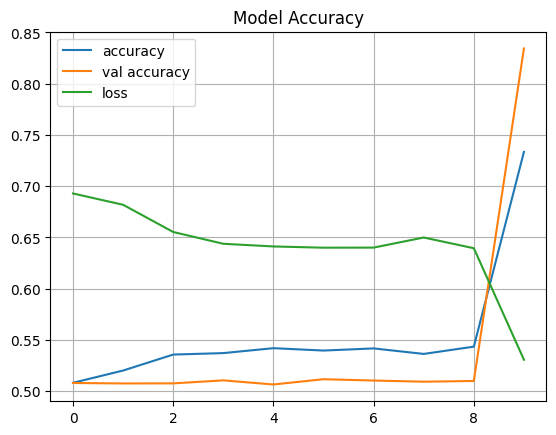

In [32]:
plt.plot(history_lstm.history['accuracy'], label = 'accuracy')
plt.plot(history_lstm.history['val_accuracy'], label = 'val accuracy')
plt.plot(history_lstm.history['loss'], label = 'loss')
plt.title('Model Accuracy')
plt.grid()
plt.legend()

**GRU Model**

In [33]:
model_gru = Sequential([
    Embedding(10000, 50, input_length=500),
    GRU(32),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [34]:
model_gru.compile(loss='binary_crossentropy', optimizer='adam',
                 metrics=['accuracy'])

In [35]:
history_gru = model_gru.fit(padded, training_labels, epochs=10,
                       validation_data=(testing_padded, testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.5037 - loss: 0.6929 - val_accuracy: 0.5053 - val_loss: 0.6929
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5197 - loss: 0.6856 - val_accuracy: 0.5088 - val_loss: 0.6979
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5328 - loss: 0.6641 - val_accuracy: 0.5060 - val_loss: 0.7085
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5381 - loss: 0.6495 - val_accuracy: 0.5061 - val_loss: 0.7337
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5407 - loss: 0.6433 - val_accuracy: 0.5079 - val_loss: 0.7475
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7277 - loss: 0.5045 - val_accuracy: 0.8495 - val_loss: 0.3850
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9091 - loss: 0.2394 - val_accuracy: 0.8609 - val_loss: 0.3630
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9499 - loss: 0.1453 - 

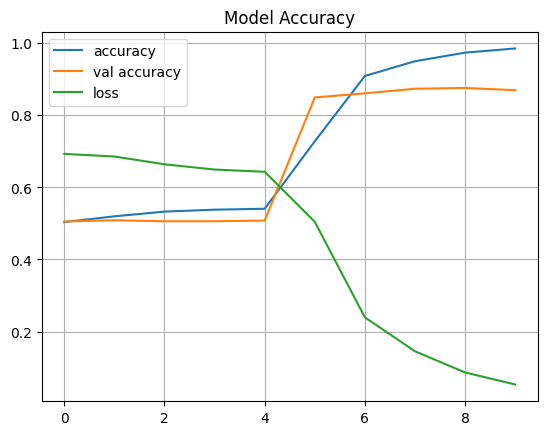

In [36]:
plt.plot(history_gru.history['accuracy'], label = 'accuracy')
plt.plot(history_gru.history['val_accuracy'], label = 'val accuracy')
plt.plot(history_gru.history['loss'], label = 'loss')
plt.title('Model Accuracy')
plt.grid()
plt.legend()

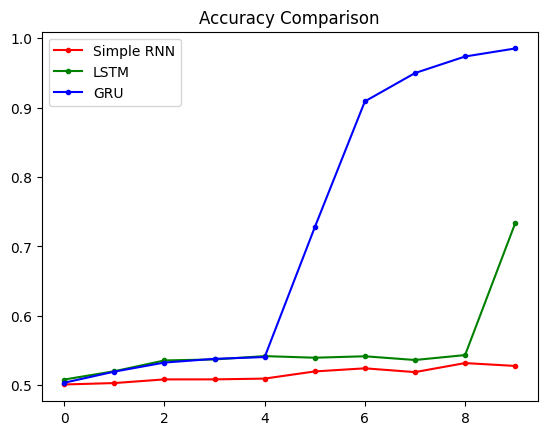

In [37]:
plt.title('Accuracy Comparison')
plt.plot(history.history['accuracy'], label = 'Simple RNN', color = 'r', marker = '.')
plt.plot(history_lstm.history['accuracy'], label = 'LSTM', color = 'g', marker = '.')
plt.plot(history_gru.history['accuracy'], label = 'GRU', color = 'b', marker = '.')
plt.legend()

In [ ]:
new1 = 'This was worst moview. Please do not watch it. WAste of money and time.'
new2 = 'A must watch movie. I lived to watch it. It was just amazing.'